<a href="https://colab.research.google.com/github/dennisddschulz/cas-artificial-intelligence/blob/main/06_transformer/04_Assignment_%E2%80%93_Encoder_Decoder_mit_Attention_(Seq2Seq)_%26_Br%C3%BCcke_zu_Transformern_Aufgabe_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 Assignment – Encoder-Decoder mit Attention (Seq2Seq) & Brücke zu Transformern

Bern University of Applied Sciences – CAS AI HS 25  
Dozent: Ilja Rasin  

Dieses Notebook gehört zur vierten Vorlesung (Transformer & Attention).

**Ziele der Einheit**

- Wiederholung: LSTM als Baustein für Sequenzmodelle  
- Encoder-Decoder-Architektur (Seq2Seq) verstehen  
- Dot-Product-Attention auf Basis von LSTM implementieren  
- Attention-Gewichte visualisieren (Heatmap)  
- Einen ersten Blick auf "große" Transformer-Modelle mit Hugging Face werfen

## 1. Imports & Setup

In [48]:

import math
import random
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Mini-Datensatz: einfache “Übersetzung”

In [79]:
pairs = [
    ("eins zwei drei", "one two three"),
    ("vier fünf", "four five"),
    ("eins zwei", "one two"),
    ("drei vier fünf", "three four five"),
    ("wir lieben pytorch", "we love pytorch"),
    ("ich lerne ki", "i learn ai"),
    ("hallo welt", "hello world"),
    ("guten morgen", "good morning"),
    ("wie geht es dir", "how are you"),
    ("ich bin gut", "i am good"),
    ("das ist toll", "that is great"),
    ("das ist ein sehr langes und komplexes beispiel", "this is a very long and complex example"),
    ("der himmel ist blau und die sonne scheint hell", "the sky is blue and the sun shines brightly"),
    ("bitte übersetze diesen satz für mich", "please translate this sentence for me"),
    ("wir müssen mehr über neuronale netze lernen", "we must learn more about neural networks"),
    ("ich möchte heute abend einen film schauen", "i want to watch a movie tonight"),
    ("die künstliche intelligenz verändert die welt", "artificial intelligence is changing the world"),
    ("mein computer ist schnell und zuverlässig", "my computer is fast and reliable"),
    ("dieses beispiel sollte länger sein als die anderen", "this example should be longer than the others"),
]

# Wir fügen zusätzlich ein paar Zufallsvarianten auf Basis der Zahlen ein
de_numbers = ["eins", "zwei", "drei", "vier", "fünf"]
en_numbers = ["one", "two", "three", "four", "five"]

for _ in range(50): # Erhöhte die Anzahl der Zufallsbeispiele von 25 auf 50
    length = random.randint(3, 6) # Erhöhen Sie die maximale Länge der Zufallszahlen
    idxs = [random.randint(0, 4) for _ in range(length)]
    src = " ".join(de_numbers[i] for i in idxs)
    trg = " ".join(en_numbers[i] for i in idxs)
    pairs.append((src, trg))

len(pairs), pairs[:20]

(69,
 [('eins zwei drei', 'one two three'),
  ('vier fünf', 'four five'),
  ('eins zwei', 'one two'),
  ('drei vier fünf', 'three four five'),
  ('wir lieben pytorch', 'we love pytorch'),
  ('ich lerne ki', 'i learn ai'),
  ('hallo welt', 'hello world'),
  ('guten morgen', 'good morning'),
  ('wie geht es dir', 'how are you'),
  ('ich bin gut', 'i am good'),
  ('das ist toll', 'that is great'),
  ('das ist ein sehr langes und komplexes beispiel',
   'this is a very long and complex example'),
  ('der himmel ist blau und die sonne scheint hell',
   'the sky is blue and the sun shines brightly'),
  ('bitte übersetze diesen satz für mich',
   'please translate this sentence for me'),
  ('wir müssen mehr über neuronale netze lernen',
   'we must learn more about neural networks'),
  ('ich möchte heute abend einen film schauen',
   'i want to watch a movie tonight'),
  ('die künstliche intelligenz verändert die welt',
   'artificial intelligence is changing the world'),
  ('mein computer is

## 3. Vokabular & Tokenisierung

### Ausführliche Erklärung

itos steht für index-to-string.
Das heißt: Wenn wir einen Index haben, können wir damit das entsprechende Wort (Token) nachschlagen.

Beim Aufbau des Vokabulars (build_vocab) erzeugen wir eine Liste aller Tokens, die die Reihenfolge festlegt.

Diese Liste sieht z. B. so aus:
```
itos = [
    "<pad>",    # Index 0
    "<sos>",    # Index 1
    "<eos>",    # Index 2
    "drei",     # Index 3
    "eins",     # Index 4
    "fünf",     # Index 5
    "vier",     # Index 6
    "zwei"      # Index 7
]
```

Damit wird klar:

```itos[0] == "<pad>"```
Das Token <pad> (“Padding”) hat den Index 0.
Es wird verwendet, um Sequenzen auf gleiche Länge zu bringen.

```itos[1] == "<sos>"```
<sos> (“start of sequence”) hat den Index 1.
Der Decoder beginnt die Generierung immer mit diesem Token.

```itos[2] == "<eos>"```
<eos> (“end of sequence”) hat den Index 2.
Sobald der Decoder dieses Token ausgibt, ist der Satz beendet.

```itos[3] == "drei"```
Das tatsächliche Wort „drei“ bekommt den Index 3.
Es ist das erste „echte“ Wort im Vokabular nach den drei Spezial-Tokens.

**Warum genau in dieser Reihenfolge?**

Die drei Sondertokens haben immer feste Plätze (0, 1, 2).
Das macht Training und Paddings logischer und reproduzierbar.

Alle anderen Wörter (z. B. „drei“, „eins“, „zwei“ …) werden alphabetisch sortiert eingefügt.
Das hat keinen Einfluss auf das Lernen, sorgt aber dafür, dass das Vokabular jedes Mal im selben Aufbau entsteht.

In [80]:
# Spezielle Tokens

# "<pad>" — padding token
# "<sos>" — start-of-sequence
# "<eos>" — end-of-sequence
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def build_vocab(sentences: List[str]):
    tokens = set()
    for s in sentences:
        tokens.update(s.split())

    # itos — index-to-string
    itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + sorted(tokens)
    print("itos: ", itos)

    # itos[0] == "<pad>"
    # itos[1] == "<sos>"
    # itos[2] == "<eos>"
    # itos[3] == "drei"

    stoi = {tok: i for i, tok in enumerate(itos)}
    print("stoi: ", stoi)
    return stoi, itos

src_sentences = [p[0] for p in pairs]
trg_sentences = [p[1] for p in pairs]

src_stoi, src_itos = build_vocab(src_sentences)
trg_stoi, trg_itos = build_vocab(trg_sentences)

SRC_VOCAB_SIZE = len(src_itos)
TRG_VOCAB_SIZE = len(trg_itos)

SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, src_itos, trg_itos


itos:  ['<pad>', '<sos>', '<eos>', 'abend', 'als', 'anderen', 'beispiel', 'bin', 'bitte', 'blau', 'computer', 'das', 'der', 'die', 'diesen', 'dieses', 'dir', 'drei', 'ein', 'einen', 'eins', 'es', 'film', 'fünf', 'für', 'geht', 'gut', 'guten', 'hallo', 'hell', 'heute', 'himmel', 'ich', 'intelligenz', 'ist', 'ki', 'komplexes', 'künstliche', 'langes', 'lerne', 'lernen', 'lieben', 'länger', 'mehr', 'mein', 'mich', 'morgen', 'möchte', 'müssen', 'netze', 'neuronale', 'pytorch', 'satz', 'schauen', 'scheint', 'schnell', 'sehr', 'sein', 'sollte', 'sonne', 'toll', 'und', 'verändert', 'vier', 'welt', 'wie', 'wir', 'zuverlässig', 'zwei', 'über', 'übersetze']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'abend': 3, 'als': 4, 'anderen': 5, 'beispiel': 6, 'bin': 7, 'bitte': 8, 'blau': 9, 'computer': 10, 'das': 11, 'der': 12, 'die': 13, 'diesen': 14, 'dieses': 15, 'dir': 16, 'drei': 17, 'ein': 18, 'einen': 19, 'eins': 20, 'es': 21, 'film': 22, 'fünf': 23, 'für': 24, 'geht': 25, 'gut': 26, 'guten': 27, 

(71,
 65,
 ['<pad>',
  '<sos>',
  '<eos>',
  'abend',
  'als',
  'anderen',
  'beispiel',
  'bin',
  'bitte',
  'blau',
  'computer',
  'das',
  'der',
  'die',
  'diesen',
  'dieses',
  'dir',
  'drei',
  'ein',
  'einen',
  'eins',
  'es',
  'film',
  'fünf',
  'für',
  'geht',
  'gut',
  'guten',
  'hallo',
  'hell',
  'heute',
  'himmel',
  'ich',
  'intelligenz',
  'ist',
  'ki',
  'komplexes',
  'künstliche',
  'langes',
  'lerne',
  'lernen',
  'lieben',
  'länger',
  'mehr',
  'mein',
  'mich',
  'morgen',
  'möchte',
  'müssen',
  'netze',
  'neuronale',
  'pytorch',
  'satz',
  'schauen',
  'scheint',
  'schnell',
  'sehr',
  'sein',
  'sollte',
  'sonne',
  'toll',
  'und',
  'verändert',
  'vier',
  'welt',
  'wie',
  'wir',
  'zuverlässig',
  'zwei',
  'über',
  'übersetze'],
 ['<pad>',
  '<sos>',
  '<eos>',
  'a',
  'about',
  'ai',
  'am',
  'and',
  'are',
  'artificial',
  'be',
  'blue',
  'brightly',
  'changing',
  'complex',
  'computer',
  'example',
  'fast',
  '

In [81]:
def encode_sentence(sentence: str, stoi: dict, add_sos_eos: bool = True):
    tokens = sentence.split()
    ids = [stoi[t] for t in tokens]
    if add_sos_eos:
        ids = [stoi[SOS_TOKEN]] + ids + [stoi[EOS_TOKEN]]
    return ids

max_len_src = max(len(encode_sentence(s, src_stoi)) for s in src_sentences)
max_len_trg = max(len(encode_sentence(s, trg_stoi)) for s in trg_sentences)
max_len_src, max_len_trg


(11, 11)

In [82]:
for s in src_sentences:
  encoded_ids = encode_sentence(s, src_stoi)
  print(s, encoded_ids)

eins zwei drei [1, 20, 68, 17, 2]
vier fünf [1, 63, 23, 2]
eins zwei [1, 20, 68, 2]
drei vier fünf [1, 17, 63, 23, 2]
wir lieben pytorch [1, 66, 41, 51, 2]
ich lerne ki [1, 32, 39, 35, 2]
hallo welt [1, 28, 64, 2]
guten morgen [1, 27, 46, 2]
wie geht es dir [1, 65, 25, 21, 16, 2]
ich bin gut [1, 32, 7, 26, 2]
das ist toll [1, 11, 34, 60, 2]
das ist ein sehr langes und komplexes beispiel [1, 11, 34, 18, 56, 38, 61, 36, 6, 2]
der himmel ist blau und die sonne scheint hell [1, 12, 31, 34, 9, 61, 13, 59, 54, 29, 2]
bitte übersetze diesen satz für mich [1, 8, 70, 14, 52, 24, 45, 2]
wir müssen mehr über neuronale netze lernen [1, 66, 48, 43, 69, 50, 49, 40, 2]
ich möchte heute abend einen film schauen [1, 32, 47, 30, 3, 19, 22, 53, 2]
die künstliche intelligenz verändert die welt [1, 13, 37, 33, 62, 13, 64, 2]
mein computer ist schnell und zuverlässig [1, 44, 10, 34, 55, 61, 67, 2]
dieses beispiel sollte länger sein als die anderen [1, 15, 6, 58, 42, 57, 4, 13, 5, 2]
fünf eins vier eins drei

In [83]:
def pad_sequence(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    return seq + [pad_idx] * (max_len - len(seq))

PAD_IDX_TRG = trg_stoi[PAD_TOKEN]
PAD_IDX_SRC = src_stoi[PAD_TOKEN]

dataset = []
for src, trg in pairs:
    src_ids = encode_sentence(src, src_stoi)
    trg_ids = encode_sentence(trg, trg_stoi)
    src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
    trg_ids = pad_sequence(trg_ids, max_len_trg, PAD_IDX_TRG)
    dataset.append((src_ids, trg_ids))

len(dataset), dataset[0]


(69,
 ([1, 20, 68, 17, 2, 0, 0, 0, 0, 0, 0], [1, 40, 58, 54, 2, 0, 0, 0, 0, 0, 0]))

In [84]:
# Mini-Dataloader

def batchify(dataset, batch_size: int):
    random.shuffle(dataset)
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        src_batch = torch.tensor([b[0] for b in batch], dtype=torch.long, device=device)
        trg_batch = torch.tensor([b[1] for b in batch], dtype=torch.long, device=device)
        yield src_batch, trg_batch


## 4. Encoder-Decoder ohne Attention

### Encoder

In [85]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX_SRC)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        # src: [B, src_len]
        embedded = self.embedding(src)           # [B, src_len, emb_dim]
        outputs, (hidden, cell) = self.lstm(embedded)  # outputs: [B, src_len, H]
        return outputs, (hidden, cell)


### Decoder ohne Attention

In [86]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        # input: [B] (aktuelles Token-Index)
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: [B, 1, H]
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell


## 5. Seq2Seq Wrapper

## Wie funktioniert ein Seq2Seq-Modell?
**Encoder**

- erhält die gesamte Eingabesequenz (**[eins, zwei, drei])**
- verarbeitet sie tokenweise (LSTM-Zeitdimension)
- erzeugt einen „Kontextvektor“ (hidden, cell)
- dieser Kontext repräsentiert die **Bedeutung** des ganzen Satzes

**Decoder**

- bekommt nicht die Eingabewörter
- bekommt nur den Kontext + \<sos> als Startsignal
- generiert das Zielsatz Wort für Wort

**Beispiel**:

- Source: "eins zwei drei"
- Target: "one two three"


Decoder erzeugt:

\<sos> → one
one → two
two → three
three → \<eos>


Er versucht nicht, "eins" zu rekonstruieren.
Er versucht, die Zielsequenz zu generieren.

### Seq2Seq-Klasse – ausführliche Erklärung

Der folgende Code implementiert den kompletten Ablauf eines Encoder-Decoder-Modells (Seq2Seq):
```
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg
```

Was passiert hier?

**encoder**: verarbeitet den Eingabesatz

**decoder**: generiert den Ausgabesatz

**trg_sos_idx**: Index des <sos>-Tokens

**trg_eos_idx**: Index des <eos>-Tokens

**max_len_trg**: maximale Länge der Zielsequenz

```
def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
    batch_size = src.size(0)
    trg_len = self.max_len_trg
    trg_vocab_size = self.decoder.fc_out.out_features
```

**Bedeutung**:

**batch_size**: Anzahl der Sätze im Batch

**trg_len**: wie viele Schritte der Decoder generieren soll

**trg_vocab_size**: Größe des Zielvokabulars (für Softmax)

outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)


**Wir erzeugen eine große Ausgabe-Matrix, in der der Decoder seine Vorhersagen ablegt:**
```
Form:
[Batch, Zeit, Vokabulargröße]

encoder_outputs, (hidden, cell) = self.encoder(src)
```


**Der Encoder liefert:**

encoder_outputs: alle LSTM-Outputs (für Attention)

hidden, cell: letzter versteckter Zustand — initialer Zustand des Decoders
```
input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)
```


**Der Decoder startet immer mit dem <sos>-Token.**

Hauptschleife
```
for t in range(trg_len):
    output, hidden, cell = self.decoder(input, hidden, cell)
    outputs[:, t, :] = output
```


Der Decoder arbeitet Schritt für Schritt:

1. erhält das aktuelle Token

2. aktualisiert seinen Zustand

3. produziert eine Wahrscheinlichkeitsverteilung über das Vokabular. Diese speichern wir in outputs

**Teacher Forcing**
```
if trg is not None and random.random() < teacher_forcing_ratio:
    input = trg[:, t]  # das echte Token
else:
    input = output.argmax(dim=1)  # das vorhergesagte Token
```

**Teacher Forcing: schnelleres Lernen**

Ohne Teacher Forcing: Modell lernt, selbstständig zu generieren

Rückgabe
```
return outputs
```

Ein Tensor der Form:
```
[Batch, Sequenzlänge, Vokabulargröße]
```

### Teacher Forcing – Erklärung auf Deutsch für Studierende

Teacher Forcing ist eine Trainingsstrategie im Decoder eines Seq2Seq-Modells.

Bei jedem Zeitschritt entscheidet das Modell:

Soll ich das nächste Wort anhand des korrekten Trainingstokens erzeugen
oder anhand meines eigenen vorherigen Outputs?

- Mit Teacher Forcing

Der Decoder erhält das richtige Wort aus der Zielsequenz.
Dadurch lernt er schneller und sammelt keine Fehler auf.

- Ohne Teacher Forcing

Der Decoder erhält sein eigenes vorhergesagtes Wort.
Das ist wichtig, um später autonom Sätze zu generieren.

> **Problem ohne Teacher Forcing**

Wenn der Decoder früh einen Fehler macht, baut sich dieser Fehler auf —
die gesamte Ausgabe kann kollabieren.

> **Lösung**

Wir mischen beides, z. B. teacher_forcing_ratio = 0.5:

if random.random() < teacher_forcing_ratio:
    input = target_token     # richtiges Token
else:
    input = predicted_token  # Modellvorhersage


So lernt der Decoder korrekt zu folgen aber auch selbstständig zu generieren

Das ergibt robustes Seq2Seq-Verhalten.

In [57]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs


## Model + Loss

In [58]:
EMB_DIM = 64
HID_DIM = 128

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder = Decoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model = Seq2Seq(
    encoder,
    decoder,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training (erstmal ohne Attention)

In [59]:
def train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer.zero_grad()
        outputs = model(src_batch, trg_batch, teacher_forcing_ratio)
        # outputs: [B, T, V]
        B, T, V = outputs.shape
        loss = criterion(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(100): # Erhöhte Epochenzahl
    loss = train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"Epoch {epoch+1}: loss={loss:.3f}")

Epoch 1: loss=4.488
Epoch 2: loss=4.179
Epoch 3: loss=3.652
Epoch 4: loss=3.045
Epoch 5: loss=2.902
Epoch 6: loss=2.736
Epoch 7: loss=2.672
Epoch 8: loss=2.547
Epoch 9: loss=2.511
Epoch 10: loss=2.386
Epoch 11: loss=2.481
Epoch 12: loss=2.370
Epoch 13: loss=2.330
Epoch 14: loss=2.176
Epoch 15: loss=2.211
Epoch 16: loss=2.128
Epoch 17: loss=1.986
Epoch 18: loss=1.977
Epoch 19: loss=1.932
Epoch 20: loss=1.938
Epoch 21: loss=1.854
Epoch 22: loss=1.814
Epoch 23: loss=1.706
Epoch 24: loss=1.780
Epoch 25: loss=1.654
Epoch 26: loss=1.664
Epoch 27: loss=1.554
Epoch 28: loss=1.560
Epoch 29: loss=1.471
Epoch 30: loss=1.419
Epoch 31: loss=1.388
Epoch 32: loss=1.341
Epoch 33: loss=1.318
Epoch 34: loss=1.284
Epoch 35: loss=1.247
Epoch 36: loss=1.176
Epoch 37: loss=1.100
Epoch 38: loss=1.058
Epoch 39: loss=1.030
Epoch 40: loss=0.972
Epoch 41: loss=0.936
Epoch 42: loss=0.870
Epoch 43: loss=0.863
Epoch 44: loss=0.811
Epoch 45: loss=0.760
Epoch 46: loss=0.773
Epoch 47: loss=0.755
Epoch 48: loss=0.664
E

## Eine Funktion zur Generierung

In [68]:
def indices_to_sentence(indices: List[int], itos: List[str]):
    tokens = []
    for idx in indices:
        tok = itos[idx]
        if tok == EOS_TOKEN:
            break
        if tok not in (SOS_TOKEN, PAD_TOKEN):
            tokens.append(tok)
    return " ".join(tokens)

def translate_example(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        # outputs: [1, T, V]
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        return indices_to_sentence(preds, trg_itos)

for s, t in random.sample(pairs, 20):
    pred = translate_example(model, s)
    print(f"DE: {s}")
    print(f"GT: {t}")
    print(f"PR: {pred}\n")


DE: zwei zwei fünf fünf drei
GT: two two five five three
PR: two two five five three

DE: drei drei zwei zwei drei eins
GT: three three two two three one
PR: three three two two three one

DE: vier vier fünf
GT: four four five
PR: four four five

DE: zwei vier vier vier zwei
GT: two four four four two
PR: two four four four two

DE: ich möchte heute abend einen film schauen
GT: i want to watch a movie tonight
PR: i want to watch a movie tonight

DE: ich bin gut
GT: i am good
PR: i am good

DE: eins eins eins zwei zwei fünf
GT: one one one two two five
PR: one one one two two five

DE: fünf drei fünf eins eins fünf
GT: five three five one one five
PR: five three five one one five

DE: hallo welt
GT: hello world
PR: hello world

DE: dieses beispiel sollte länger sein als die anderen
GT: this example should be longer than the others
PR: this example should be longer than the others

DE: vier fünf
GT: four five
PR: four five

DE: fünf zwei fünf
GT: five two five
PR: five two five

DE: eins

## 6. Dot-Product Attention hinzufügen (ATTENTION:  Attention$→$ NÄCHSTE SITZUNG!)

In [69]:
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: [B, H] (aktueller hidden state der Decoder-LSTM)
        # encoder_outputs: [B, src_len, H]
        # scores: [B, src_len]
        scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=1)  # [B, src_len]

        # Kontext: gewichtete Summe der Encoder-Outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


### Decoder mit Attention

In [70]:
class AttnDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.attention = DotProductAttention()

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: [B]
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]

        dec_hidden = hidden[-1]  # [B, H] - letzte Layer
        context, attn_weights = self.attention(dec_hidden, encoder_outputs)  # [B, H], [B, src_len]

        context = context.unsqueeze(1)  # [B, 1, H]
        lstm_input = torch.cat([embedded, context], dim=2)  # [B, 1, emb_dim + H]

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell, attn_weights


### Seq2Seq mit Attention (leicht modifiziert)

In [71]:
class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)
        all_attn = torch.zeros(batch_size, trg_len, src.size(1), device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell, attn_weights = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            all_attn[:, t, :] = attn_weights

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs, all_attn


### Model + Training

In [72]:
encoder_attn = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder_attn =  AttnDecoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model_attn = AttnSeq2Seq(
    encoder_attn,
    decoder_attn,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

optimizer_attn = optim.Adam(model_attn.parameters(), lr=1e-3)
criterion_attn = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)

def train_epoch_attn(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer_attn.zero_grad()
        outputs, _ = model(src_batch, trg_batch, teacher_forcing_ratio)
        B, T, V = outputs.shape
        loss = criterion_attn(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(50): # Erhöhte Epochenzahl
    loss = train_epoch_attn(model_attn, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"[ATTN] Epoch {epoch+1}: loss={loss:.3f}")

[ATTN] Epoch 1: loss=4.471
[ATTN] Epoch 2: loss=4.119
[ATTN] Epoch 3: loss=3.502
[ATTN] Epoch 4: loss=3.007
[ATTN] Epoch 5: loss=2.816
[ATTN] Epoch 6: loss=2.545
[ATTN] Epoch 7: loss=2.435
[ATTN] Epoch 8: loss=2.288
[ATTN] Epoch 9: loss=2.244
[ATTN] Epoch 10: loss=2.116
[ATTN] Epoch 11: loss=1.977
[ATTN] Epoch 12: loss=2.010
[ATTN] Epoch 13: loss=1.887
[ATTN] Epoch 14: loss=1.780
[ATTN] Epoch 15: loss=1.798
[ATTN] Epoch 16: loss=1.703
[ATTN] Epoch 17: loss=1.691
[ATTN] Epoch 18: loss=1.598
[ATTN] Epoch 19: loss=1.602
[ATTN] Epoch 20: loss=1.511
[ATTN] Epoch 21: loss=1.439
[ATTN] Epoch 22: loss=1.475
[ATTN] Epoch 23: loss=1.430
[ATTN] Epoch 24: loss=1.409
[ATTN] Epoch 25: loss=1.349
[ATTN] Epoch 26: loss=1.296
[ATTN] Epoch 27: loss=1.201
[ATTN] Epoch 28: loss=1.164
[ATTN] Epoch 29: loss=1.117
[ATTN] Epoch 30: loss=1.041
[ATTN] Epoch 31: loss=1.012
[ATTN] Epoch 32: loss=0.937
[ATTN] Epoch 33: loss=0.884
[ATTN] Epoch 34: loss=0.852
[ATTN] Epoch 35: loss=0.836
[ATTN] Epoch 36: loss=0.771
[

### Eine Funktion zur Übersetzung und Visualisierung der Attention

Quellsatz: fünf zwei fünf
Vorhersage: five two five


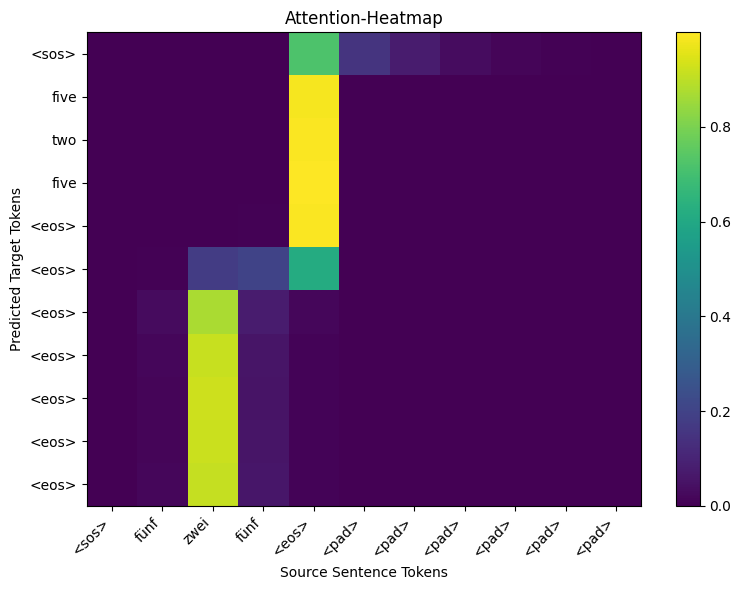

In [77]:
def translate_with_attention(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs, attn = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        attn = attn.squeeze(0).cpu().numpy()  # [trg_len, src_len]

        pred_sentence = indices_to_sentence(preds, trg_itos)
        return pred_sentence, attn, src_ids, preds

example_src = random.choice(pairs)[0]
pred_sentence, attn_matrix, src_ids, raw_preds = translate_with_attention(model_attn, example_src)

print("Quellsatz:", example_src)
print("Vorhersage:", pred_sentence)

src_tokens = [src_itos[i] for i in src_ids]

# Neue trg_tokens, um alle vorhergesagten Schritte anzuzeigen, auch Padding
trg_tokens_for_plot = [trg_itos[i] for i in raw_preds]

plt.figure(figsize=(8, 6))
plt.imshow(attn_matrix[:len(trg_tokens_for_plot), :len(src_tokens)], aspect='auto')
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha='right')
plt.yticks(range(len(trg_tokens_for_plot)), trg_tokens_for_plot)
plt.colorbar()
plt.title("Attention-Heatmap")
plt.xlabel("Source Sentence Tokens")
plt.ylabel("Predicted Target Tokens")
plt.tight_layout()
plt.show()


## 7. Mini-HuggingFace Demo: “Großer” Transformer

In [66]:
!pip install -q transformers sentencepiece

In [78]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-de-en"  # kleiner Übersetzungs-Transformer
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def translate_hf(text: str):
    inputs = tokenizer_hf(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_hf.generate(**inputs, max_new_tokens=50)
    return tokenizer_hf.batch_decode(outputs, skip_special_tokens=True)[0]

example_text = "Wir lernen heute Attention und Transformer."
print(translate_hf(example_text))


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


We're learning attention and transformer today.


### Aufgabe (HuggingFace)

1. Ändern Sie `example_text` und testen Sie eigene Sätze.  
2. Probieren Sie (optional) ein anderes Modell aus, z.B.:
   - Summarization (`google/pegasus-xsum`)
   - Deutsch-Deutsch-Paraphrasierung o.ä.  

> Ziel: Gefühl dafür bekommen, wie Tokenizer + Transformer-Modell in der Praxis zusammenspielen.


## 8. Übungsaufgaben (Summary)

## Übungsaufgaben

1. **Eigene Sätze einbauen (Seq2Seq LSTM OHNE Attention)**  
   - Erweitern Sie die Liste `pairs` um eigene kleine Satzpaare (DE->EN oder sonstige Mapping-Aufgabe).  
   - Beobachten Sie, ob das Modell diese neuen Beispiele lernen kann.

2. **Hyperparameter-Experimente**  
   - Ändern Sie `EMB_DIM` und `HID_DIM`.  
   - Wie verändert sich die Trainingszeit und die Qualität der Vorhersagen?

3. **Hugging Face Exploration**  
   - Ändern Sie den Text in der HF-Demo und erläutern Sie in 2–3 Sätzen, was der Unterschied zwischen  
     unserem LSTM-Seq2Seq und dem vortrainierten Transformer-Modell ist (Datenmenge, Architektur, Qualität).
4. **Optionaler Task: Seq2Seq Forecasting (ohne Attention)**

Wir verwenden die bereits bekannte Encoder–Decoder Struktur aus der heutigen Vorlesung, aber diesmal nicht für Sprache, sondern für Zeitreihen.

**Ziel:**
Geben Sie die vergangenen n Werte in den Encoder und lassen Sie den Decoder die nächsten n Werte generieren.

**Hinweise:**

1. Entfernen Sie das Embedding — Zeitreihen sind numerisch.

2. src (Encoder Input) und trg (Decoder Target) sollen gleich lang sein.

3. \<sos> kann z.B. 0.0 sein oder ein learnable Parameter.

Der Decoder arbeitet autoregressiv:

\<sos> → y₁

y₁ → y₂

y₂ → y₃
… usw.

**Beispiel:**

Encoder Input:
x[t-9], x[t-8], …, x[t]

Decoder Output:
x[t+1], x[t+2], …, x[t+10]

# **Aufgabe:**
> Trainieren Sie das Modell auf Ihrem Datensatz und vergleichen Sie Seq2Seq LSTM Forecasting mit dem reinen LSTM aus der letzten Übung.
